# Density Based Spatial Clustering of Applications with Noise(DBCSAN)
is a popular clustering algorithm used in machine learning and data analysis. Unlike k-means, which assumes clusters are spherical, DBSCAN can detect clusters of arbitrary shape and identify outliers (noise).

# How DBSCAN Works
DBSCAN groups points based on two parameters:

1. ε (epsilon) – The maximum distance between two points for them to be considered neighbors.

2. MinPts – The minimum number of points required to form a dense region (core point).


The algorithm classifies points into:

Core points: Points with at least MinPts neighbors within ε.

Border points: Points within ε of a core point but with fewer than MinPts neighbors.

Noise points: Points that are neither core nor border points.

# Steps of DBSCAN
Select an unvisited point randomly.

If the point has at least MinPts neighbors within ε, it becomes a core point, and a new cluster is formed.

Expand the cluster by recursively adding all density-reachable points.

If a point does not meet the MinPts requirement, mark it as noise (it may later be part of a cluster if found near another core point).

Repeat until all points are visited.

# Advantages of DBSCAN
Can find clusters of arbitrary shape.

Does not require specifying the number of clusters in advance (unlike k-means).

Robust to noise and outliers.

# Limitations
Sensitive to the choice of ε and MinPts.

Struggles with varying densities.

Computationally expensive for large datasets.

# Python implementation of DBSCAN

#  DBSCAN on a Simple Dataset
create a small dataset with three clusters and some noise, then apply DBSCAN.

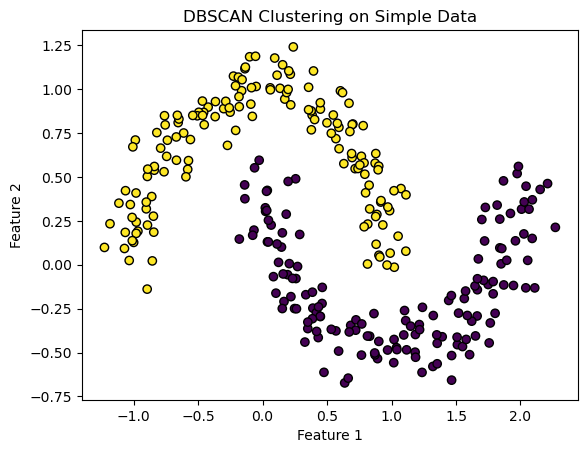

In [ ]:
# necessary libraries
import numpy as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons # Generates a synthetic dataset with two crescent-shaped clusters.

# generate sample data (moon-shaped clusters)
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.2,min_samples=5)
# eps=0.2: Defines the maximum distance between two points to be considered neighbors
# min_samples=5: Minimum number of points required to form a dense region.
labels = dbscan.fit_predict(X)

# plot results
plt.scatter(X[:,0], X[:,1],c=labels, cmap='viridis',marker = 'o',edgecolors='k')
plt.title("DBSCAN Clustering on Simple Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# DBSCAN on a Real-World Dataset
We'll use the Mall Customers dataset, which contains customer spending scores.

I'll fetch the dataset and implement DBSCAN.

## Steps Covered in the Code:
Load the dataset (Mall Customers dataset)

Preprocess the data (select relevant features, scale data)

Apply DBSCAN for clustering

Visualize the results

In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


In [5]:
# Load dataset
df = pd.read_csv("C:\\Users\\franc\\Datascience_python\\dataset\\Mall_Customers.csv")
# Display first few rows
print(df.head(5))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [6]:
# Select relevant features for clustering
# We'll use 'Annual Income (k$)' and 'Spending Score (1-100)'
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values


In [7]:
# Standardize the data to bring all features to the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [49]:
# Apply DBSCAN clustering
# eps: Maximum distance between two points to be considered neighbors
# min_samples: Minimum number of points required to form a dense region
dbscan = DBSCAN(eps=0.45, min_samples=10)
labels = dbscan.fit_predict(X_scaled)

In [50]:
# Add cluster labels to the original dataset
df['Cluster'] = labels

In [51]:
# Display unique clusters (DBSCAN assigns -1 to noise points)
unique_clusters = np.unique(labels)
print("Unique clusters found :",unique_clusters )

Unique clusters found : [-1  0  1  2  3  4]


# 5 Valid Clusters (0, 1, 2, 3, 4)

The dataset has been grouped into 5 meaningful clusters (numbered from 0 to 4).

Each cluster represents a group of customers with similar spending behavior and income levels

# Noise Cluster (-1)

DBSCAN assigns -1 to outliers (noise points).

These are customers that don’t fit well into any cluster and are isolated.

They could be very high-income or low-spending customers that do not follow the main patterns.

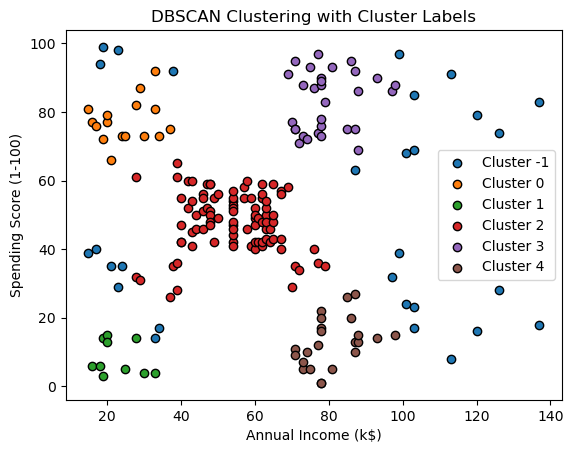

In [53]:
# Loop through each cluster and plot points
for cluster in unique_clusters:
    cluster_points = X[labels == cluster]  # Get points belonging to the cluster
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster}', edgecolors='k')

# Add labels and legend
plt.title("DBSCAN Clustering with Cluster Labels")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

# Business Insights from These Clusters:
Cluster	    Possible Interpretation

Cluster 4	High-income, low-spending customers (potential customers to target)

Cluster 3	High-income, high-spending customers (VIP customers)

Cluster 2	Medium-income, medium-spending customers

Cluster 1	Low-income, low-spending customers (budget-conscious shoppers)

Cluster 0	Low-income, high-spending customers (risky segment)

Cluster -1	Noise/outliers – Customers with unusual behavior